# 실습 3-1 : Random Forest

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 분류 데이터 (MachineFailure)
- 회귀 데이터 (Concrete)

2. Random Forest Classifier
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

3. Random Forest Regressor
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

4. 하이퍼 파라미터 최적화
- GridSearchCV를 활용한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

---

## 1) 분류 문제

In [2]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_cls_data.csv"))
MF_Data.head()

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No


In [3]:
print("데이터 크기 :", MF_Data.shape)
print("출력변수 분포:")
print(MF_Data["Failure"].value_counts())

데이터 크기 : (7900, 20)
출력변수 분포:
Failure
No     7825
Yes      75
Name: count, dtype: int64


In [4]:
# 입출력 변수 분할
Y_cls = MF_Data["Failure"]
X_cls = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X_cls["Measure2"] = X_cls["Measure2"].astype("category")
X_cls["Measure3"] = X_cls["Measure3"].astype("category")
X_cls = pd.get_dummies(X_cls)
cls_columns = X_cls.columns

# 출력변수 인코딩
Y_cls = Y_cls.replace({"No": 0, "Yes": 1})

# 데이터 분할
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


C:\Users\pisce\AppData\Local\Temp\ipykernel_28816\2999565116.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_cls = Y_cls.replace({"No": 0, "Yes": 1})


In [5]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

---

### 1-1) Random Forest Classifier 모델 학습 및 성능 평가

> **Random Forest**는 Bagging의 일종으로, 붓스트랩 샘플링 + 무작위 변수 선택을 통해 다수의 의사결정나무를 생성하고 결합하는 앙상블 모델임
> - **붓스트랩 샘플링**: 학습 데이터에서 복원 추출로 여러 표본을 만들어 베이스 모델의 다양성을 확보함
> - **무작위 변수 선택**: 각 노드마다 입력변수의 일부만 랜덤 선택하여 트리 간 상관성을 줄임
> - 분류: 다수결 투표, 회귀: 평균으로 최종 예측을 수행함

In [6]:
RF_cls = RandomForestClassifier()
RF_cls.fit(X_train_cls, Y_train_cls)
RF_cls_pred = RF_cls.predict(X_test_cls)
get_classscore(Y_test_cls, RF_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
F1-score  : 0.811

혼동행렬
[[2348    0]
 [   7   15]]


### 1-2) 변수 중요도 시각화

> Random Forest는 **Mean Decrease in Impurity** 방식으로 변수 중요도를 산출함

> 각 트리에서 특정 변수가 노드 분할에 사용될 때의 불순도 감소량을 평균내어 중요도를 계산함

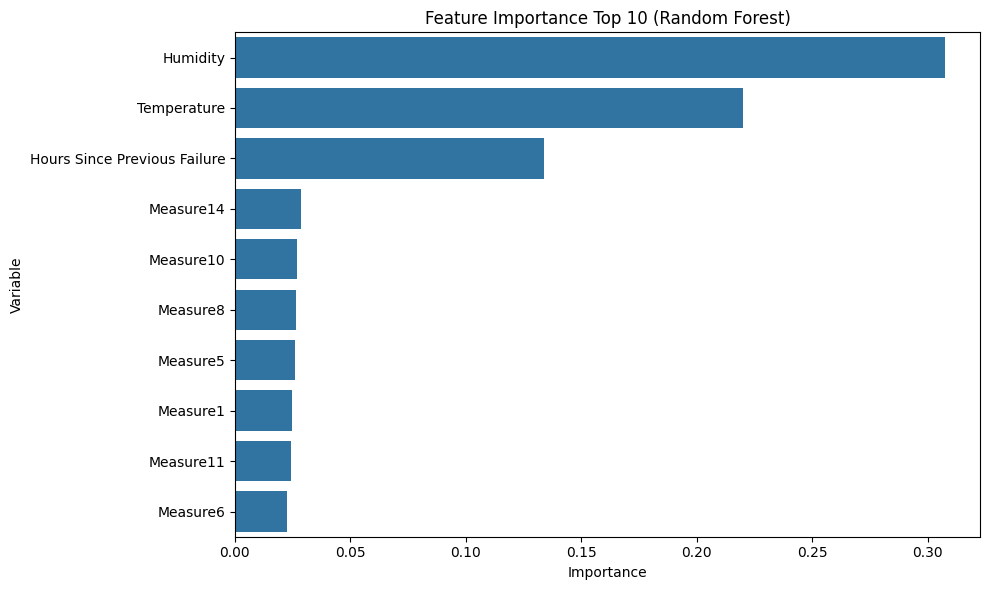

In [7]:
# 변수 중요도 추출 및 시각화
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_top10 = var_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10)
plt.title("Feature Importance Top 10 (Random Forest)")
plt.tight_layout()
plt.show()

### 1-3) 모델 성능 개선

> Random Forest의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | n_estimators | 베이스 모델(의사결정나무)의 수 |
> | max_depth | 개별 트리의 최대 깊이 |
> | max_features | 각 노드에서 랜덤 선택하는 변수 수 (분류: sqrt, 회귀: n/3) |
> | min_samples_leaf | 끝 노드의 최소 샘플 수 |
> | min_samples_split | 노드 분할을 위한 최소 샘플 수 |

In [ ]:
params = {
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [2, 4, 8],
    "n_estimators": [100, 300],
    "max_features": ["sqrt", 3]
}

grid_cls = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params, cv=5, scoring="f1", n_jobs=-1
)
grid_cls.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls.best_params_)
print("최적 F1-score: %.4f" % grid_cls.best_score_)

In [ ]:
# 최적 모델로 테스트 성능 평가
best_pred_cls = grid_cls.predict(X_test_cls)
get_classscore(Y_test_cls, best_pred_cls)

---

## 2) 회귀 문제

In [8]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


In [9]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 2-1) Random Forest Regressor 모델 학습 및 성능 평가

In [10]:
RF_reg = RandomForestRegressor()
RF_reg.fit(X_train_reg, Y_train_reg)
RF_reg_pred = RF_reg.predict(X_test_reg)
get_regscore(Y_test_reg, RF_reg_pred)

MSE       : 26.452
RMSE      : 5.143
MAE       : 3.583
R-squared : 0.897


### 2-2) 변수 중요도 시각화

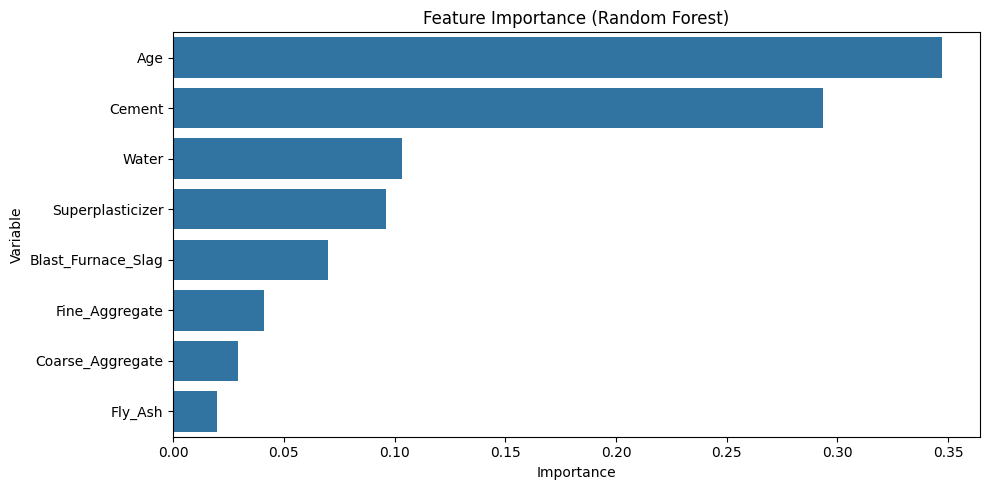

In [11]:
var_imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
var_imp_reg = var_imp_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_reg)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

### 2-3) 예측 시각화

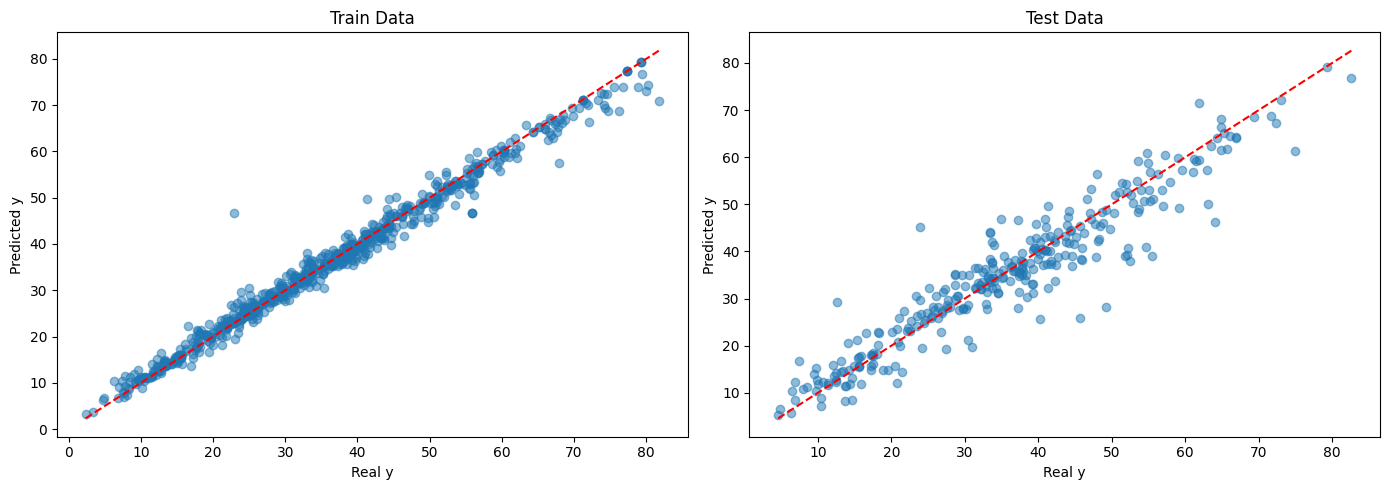

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_train_reg, RF_reg.predict(X_train_reg), alpha=0.5)
axes[0].plot([Y_train_reg.min(), Y_train_reg.max()], [Y_train_reg.min(), Y_train_reg.max()], "r--")
axes[0].set_xlabel("Real y"); axes[0].set_ylabel("Predicted y"); axes[0].set_title("Train Data")

axes[1].scatter(Y_test_reg, RF_reg_pred, alpha=0.5)
axes[1].plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], "r--")
axes[1].set_xlabel("Real y"); axes[1].set_ylabel("Predicted y"); axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 2-4) 모델 성능 개선

In [ ]:
params_reg = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [2, 4],
    "n_estimators": [100, 300]
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=params_reg, cv=5, scoring="r2", n_jobs=-1
)
grid_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg.best_params_)
print("최적 R-squared: %.4f" % grid_reg.best_score_)

In [ ]:
# 최적 모델로 테스트 성능 평가
best_pred_reg = grid_reg.predict(X_test_reg)
get_regscore(Y_test_reg, best_pred_reg)

---

## 5) Vibe Coding 실습

**[과제 1]**
지수는 Random Forest가 계산한 변수 중요도(Feature Importance)가 정말 중요한 변수를 의미하는지 궁금해졌습니다. AI와 상의하여 변수 중요도를 확인하고, 중요도가 높은 상위 변수만 사용했을 때와 전체 변수를 사용했을 때의 성능을 비교해 보세요. 결과를 바탕으로 "중요한 변수만 사용하면 항상 좋은 모델이 될까?"에 대해 자신의 의견을 정리해 보세요.

[프롬프트]

회귀 데이터셋과 분류 데이터셋에 대해 Random Forest 모델 결과를 도출했었어.
주요하다고 나타난 변수들 몇개만 가지고 학습해도 성능이 비슷한지 궁금한데

1. 주요하다고 판단할만한 수치를 말해주고
2. 해당 수치 기반으로 했을 때 각 데이터셋에서 유의미한 변수만 남기는 코드를 주고
3. 새로운 Random Forest 모델을 학습하고 예측하는 코드 주고
4. 모든 변수로 학습했던 것과 주요 변수로만 학습했던 것을 한눈에 비교하는 코드도 줘.

한 번에 4가지를 다 수행하지말고 1번에 대해서 "ok"를 하면 2번으로 넘어가는 방식으로 해줘.

In [13]:
# ─── 분류: 유의미한 변수 선택 ───────────────────────────────────────────────
import numpy as np
import pandas as pd

# 변수 중요도 DataFrame 생성 (내림차순 정렬)
var_imp_cls = pd.DataFrame({
    "Variable": cls_columns,
    "Importance": RF_cls.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# 누적 중요도 계산
var_imp_cls["Cumulative"] = var_imp_cls["Importance"].cumsum()

print("=== 분류: 변수별 중요도 (상위 15개) ===")
print(var_imp_cls.head(15).to_string(index=False))
print()

# 누적 중요도 90% 이내의 변수 선택
threshold = 0.80
selected_cls = var_imp_cls[var_imp_cls["Cumulative"] <= threshold]["Variable"].tolist()

# 마지막으로 90%를 넘기는 변수 1개 추가 (경계 포함)
if len(selected_cls) < len(var_imp_cls):
    next_var = var_imp_cls.iloc[len(selected_cls)]["Variable"]
    selected_cls.append(next_var)

print(f"선택된 변수 수: {len(selected_cls)} / {len(cls_columns)}")
print("선택된 변수:", selected_cls)

# 선택된 변수만으로 학습/테스트 데이터 재구성
X_train_cls_sel = X_train_cls[selected_cls]
X_test_cls_sel  = X_test_cls[selected_cls]

=== 분류: 변수별 중요도 (상위 15개) ===
                    Variable  Importance  Cumulative
                    Humidity    0.307253    0.307253
                 Temperature    0.220075    0.527327
Hours Since Previous Failure    0.133954    0.661282
                   Measure14    0.028750    0.690032
                   Measure10    0.026962    0.716994
                    Measure8    0.026638    0.743632
                    Measure5    0.025823    0.769455
                    Measure1    0.024661    0.794116
                   Measure11    0.024165    0.818281
                    Measure6    0.022607    0.840889
                    Measure7    0.021868    0.862757
                    Measure4    0.019681    0.882438
                    Measure9    0.019415    0.901853
                   Measure13    0.018900    0.920753
                   Measure12    0.017182    0.937935

선택된 변수 수: 9 / 31
선택된 변수: ['Humidity', 'Temperature', 'Hours Since Previous Failure', 'Measure14', 'Measure10', 'Measure8',

In [14]:
# ─── 회귀: 유의미한 변수 선택 ───────────────────────────────────────────────

# 변수 중요도 DataFrame 생성 (내림차순 정렬)
var_imp_reg = pd.DataFrame({
    "Variable": X_reg.columns,
    "Importance": RF_reg.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

var_imp_reg["Cumulative"] = var_imp_reg["Importance"].cumsum()

print("=== 회귀: 변수별 중요도 (전체) ===")
print(var_imp_reg.to_string(index=False))
print()

# importance >= 0.05 인 변수 선택
imp_threshold = 0.05
selected_reg = var_imp_reg[var_imp_reg["Importance"] >= imp_threshold]["Variable"].tolist()

print(f"선택된 변수 수: {len(selected_reg)} / {len(X_reg.columns)}")
print("선택된 변수:", selected_reg)

# 선택된 변수만으로 학습/테스트 데이터 재구성
X_train_reg_sel = X_train_reg[selected_reg]
X_test_reg_sel  = X_test_reg[selected_reg]

=== 회귀: 변수별 중요도 (전체) ===
          Variable  Importance  Cumulative
               Age    0.347026    0.347026
            Cement    0.293408    0.640435
             Water    0.103421    0.743855
  Superplasticizer    0.096074    0.839929
Blast_Furnace_Slag    0.069981    0.909911
    Fine_Aggregate    0.041248    0.951159
  Coarse_Aggregate    0.029087    0.980247
           Fly_Ash    0.019753    1.000000

선택된 변수 수: 5 / 8
선택된 변수: ['Age', 'Cement', 'Water', 'Superplasticizer', 'Blast_Furnace_Slag']


In [15]:
# ─── 분류: 선택 변수로 새 모델 학습 및 예측 ────────────────────────────────

RF_cls_sel = RandomForestClassifier(random_state=0)
RF_cls_sel.fit(X_train_cls_sel, Y_train_cls)
RF_cls_sel_pred = RF_cls_sel.predict(X_test_cls_sel)

print("=== 분류: 선택 변수 모델 성능 ===")
get_classscore(Y_test_cls, RF_cls_sel_pred)

=== 분류: 선택 변수 모델 성능 ===
Accuracy  : 0.997
Precision : 0.944
Recall    : 0.773
F1-score  : 0.850

혼동행렬
[[2347    1]
 [   5   17]]


In [16]:
# ─── 회귀: 선택 변수로 새 모델 학습 및 예측 ────────────────────────────────

RF_reg_sel = RandomForestRegressor(random_state=0)
RF_reg_sel.fit(X_train_reg_sel, Y_train_reg)
RF_reg_sel_pred = RF_reg_sel.predict(X_test_reg_sel)

print("=== 회귀: 선택 변수 모델 성능 ===")
get_regscore(Y_test_reg, RF_reg_sel_pred)

=== 회귀: 선택 변수 모델 성능 ===
MSE       : 25.622
RMSE      : 5.062
MAE       : 3.617
R-squared : 0.900


In [18]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

=== 분류 모델 성능 비교 ===
             Accuracy  Precision  Recall  F1-score
모델                                                
전체 변수 (31개)    0.9970     1.0000  0.6818    0.8108
선택 변수 (9개)     0.9975     0.9444  0.7727    0.8500



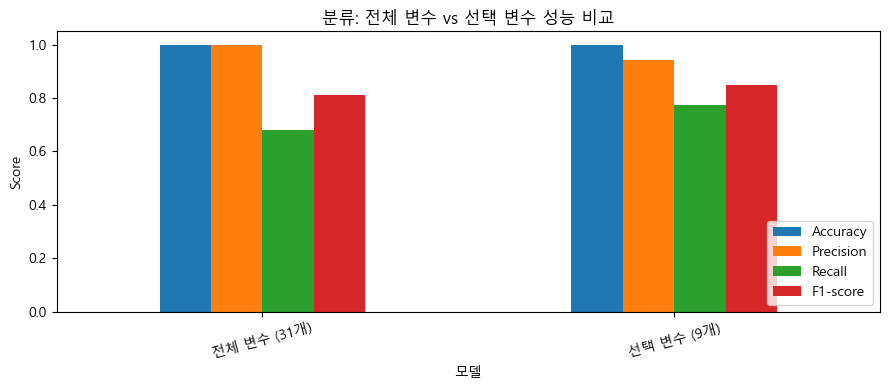

In [19]:
# ─── 분류: 전체 변수 vs 선택 변수 성능 비교 ────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def cls_summary(label, real, pred):
    return {
        "모델": label,
        "Accuracy":  round(accuracy_score(real, pred), 4),
        "Precision": round(precision_score(real, pred), 4),
        "Recall":    round(recall_score(real, pred), 4),
        "F1-score":  round(f1_score(real, pred), 4),
    }

rows_cls = [
    cls_summary(f"전체 변수 ({len(cls_columns)}개)", Y_test_cls, RF_cls_pred),
    cls_summary(f"선택 변수 ({len(selected_cls)}개)", Y_test_cls, RF_cls_sel_pred),
]

compare_cls = pd.DataFrame(rows_cls).set_index("모델")
print("=== 분류 모델 성능 비교 ===")
print(compare_cls.to_string())
print()

# 시각화
compare_cls.plot(kind="bar", figsize=(9, 4), ylim=(0, 1.05), rot=15)
plt.title("분류: 전체 변수 vs 선택 변수 성능 비교")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

=== 회귀 모델 성능 비교 ===
                R²    RMSE     MAE
모델                                
전체 변수 (8개)  0.8970  5.1432  3.5833
선택 변수 (5개)  0.9002  5.0618  3.6169



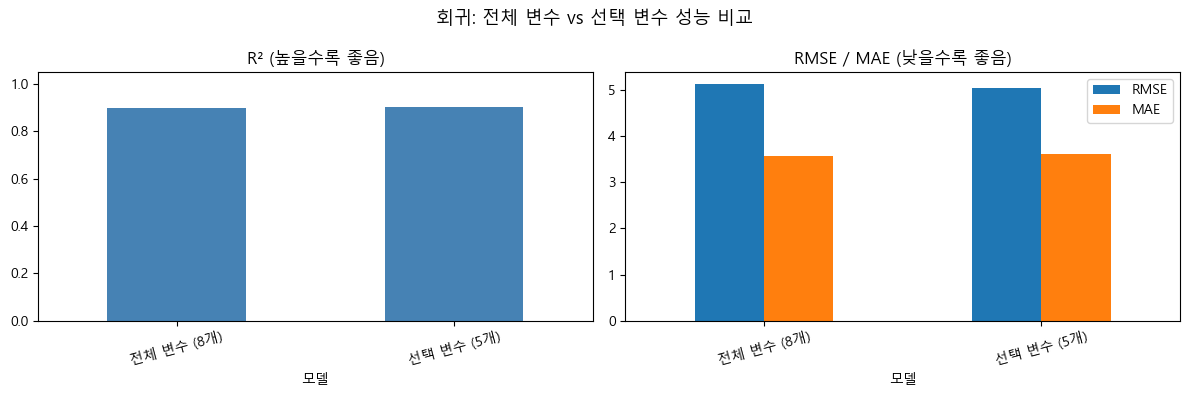

In [20]:
# ─── 회귀: 전체 변수 vs 선택 변수 성능 비교 ────────────────────────────────
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def reg_summary(label, real, pred):
    return {
        "모델":      label,
        "R²":        round(r2_score(real, pred), 4),
        "RMSE":      round(np.sqrt(mean_squared_error(real, pred)), 4),
        "MAE":       round(mean_absolute_error(real, pred), 4),
    }

rows_reg = [
    reg_summary(f"전체 변수 ({len(X_reg.columns)}개)", Y_test_reg, RF_reg_pred),
    reg_summary(f"선택 변수 ({len(selected_reg)}개)", Y_test_reg, RF_reg_sel_pred),
]

compare_reg = pd.DataFrame(rows_reg).set_index("모델")
print("=== 회귀 모델 성능 비교 ===")
print(compare_reg.to_string())
print()

# 시각화 (R²는 높을수록 좋고, RMSE·MAE는 낮을수록 좋으므로 별도 차트로 분리)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

compare_reg[["R²"]].plot(kind="bar", ax=axes[0], ylim=(0, 1.05), rot=15, color=["steelblue","tomato"])
axes[0].set_title("R² (높을수록 좋음)")
axes[0].legend().remove()

compare_reg[["RMSE", "MAE"]].plot(kind="bar", ax=axes[1], rot=15)
axes[1].set_title("RMSE / MAE (낮을수록 좋음)")

plt.suptitle("회귀: 전체 변수 vs 선택 변수 성능 비교", fontsize=13)
plt.tight_layout()
plt.show()

**[과제 2]** 지수는 Random Forest가 단일 의사결정나무보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. 동일한 데이터로 단일 의사결정나무 모델을 학습시켜 이번 실습의 Random Forest 모델과 성능을 비교해 보세요. 그리고 그 차이가 나타나는 이유를 AI와 상의하여 해석해 보세요.

In [ ]:
[프롬프트]

RandomForest가 다양한 의사결정나무를 가지고 학습하다보니 단일 트리보다 유리한지가 궁금해

1. 회귀 데이터셋으로 RandomForest 모델 학습한거랑 단일 의사결정나무 학습한거 비교하는 코드랑
2. 분류 데이터셋으로 RandomForest 모델 학습한거랑 단일 의사결정나무 학습한거 비교하는 코드 짜줘.

=== 회귀: Decision Tree vs Random Forest ===
                           R²    RMSE     MAE
모델                                           
Decision Tree (단일 트리)  0.7735  7.6245  4.8602
Random Forest          0.8970  5.1432  3.5833


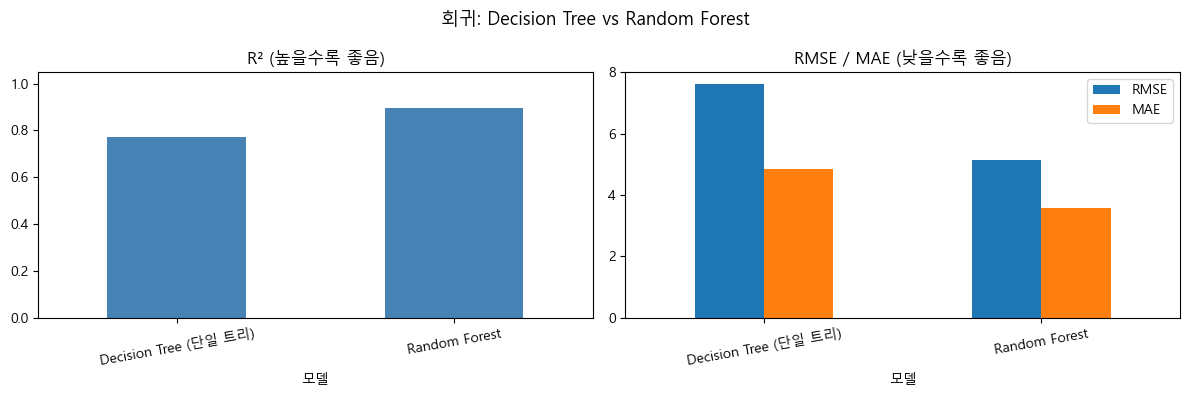

In [21]:
from sklearn.tree import DecisionTreeRegressor

# ── 단일 트리 학습 ──────────────────────────────────────────────────────────
DT_reg = DecisionTreeRegressor(random_state=0)
DT_reg.fit(X_train_reg, Y_train_reg)
DT_reg_pred = DT_reg.predict(X_test_reg)

# ── 성능 비교 표 ────────────────────────────────────────────────────────────
rows = []
for label, pred in [("Decision Tree (단일 트리)", DT_reg_pred),
                    ("Random Forest",             RF_reg_pred)]:
    rows.append({
        "모델":  label,
        "R²":   round(r2_score(Y_test_reg, pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(Y_test_reg, pred)), 4),
        "MAE":  round(mean_absolute_error(Y_test_reg, pred), 4),
    })

compare_reg_dt = pd.DataFrame(rows).set_index("모델")
print("=== 회귀: Decision Tree vs Random Forest ===")
print(compare_reg_dt.to_string())

# ── 시각화 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

compare_reg_dt[["R²"]].plot(kind="bar", ax=axes[0], ylim=(0, 1.05),
                             rot=10, color=["steelblue", "tomato"])
axes[0].set_title("R² (높을수록 좋음)")
axes[0].legend().remove()

compare_reg_dt[["RMSE", "MAE"]].plot(kind="bar", ax=axes[1], rot=10)
axes[1].set_title("RMSE / MAE (낮을수록 좋음)")

plt.suptitle("회귀: Decision Tree vs Random Forest", fontsize=13)
plt.tight_layout()
plt.show()

=== 분류: Decision Tree vs Random Forest ===
                       Accuracy  Precision  Recall  F1-score
모델                                                          
Decision Tree (단일 트리)    0.9941     0.6667  0.7273    0.6957
Random Forest            0.9970     1.0000  0.6818    0.8108


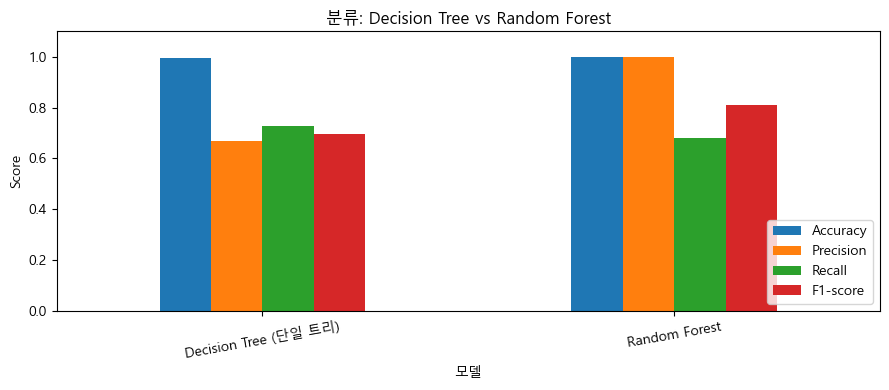

In [22]:
from sklearn.tree import DecisionTreeClassifier

# ── 단일 트리 학습 ──────────────────────────────────────────────────────────
DT_cls = DecisionTreeClassifier(random_state=0)
DT_cls.fit(X_train_cls, Y_train_cls)
DT_cls_pred = DT_cls.predict(X_test_cls)

# ── 성능 비교 표 ────────────────────────────────────────────────────────────
rows = []
for label, pred in [("Decision Tree (단일 트리)", DT_cls_pred),
                    ("Random Forest",             RF_cls_pred)]:
    rows.append({
        "모델":      label,
        "Accuracy":  round(accuracy_score(Y_test_cls, pred), 4),
        "Precision": round(precision_score(Y_test_cls, pred), 4),
        "Recall":    round(recall_score(Y_test_cls, pred), 4),
        "F1-score":  round(f1_score(Y_test_cls, pred), 4),
    })

compare_cls_dt = pd.DataFrame(rows).set_index("모델")
print("=== 분류: Decision Tree vs Random Forest ===")
print(compare_cls_dt.to_string())

# ── 시각화 ──────────────────────────────────────────────────────────────────
compare_cls_dt.plot(kind="bar", figsize=(9, 4), ylim=(0, 1.1), rot=10)
plt.title("분류: Decision Tree vs Random Forest")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**[과제 3]** 지수는 Random Forest의 성능을 더 높이기 위해 하이퍼파라미터 튜닝을 시도하려고 합니다. 하지만 n_estimators, max_depth, min_samples_split, max_features 등의 의미와 적절한 범위를 잘 모릅니다. AI와 상의하여 각 하이퍼파라미터의 역할을 이해하고 탐색 범위를 직접 설정해 보세요. 이후 GridSearchCV를 활용해 최적의 조합을 찾고, 왜 해당 조합이 선택되었는지 결과를 해석해 보세요.

In [ ]:
[프롬프트]

Random Forest에 하이퍼파라미터가 엄청 많아.

1. 주요 하이퍼파라미터에 대한 의미를 아주 쉽게 한줄로 설명해주고
2. 적절한 범위를 추천해줘
3. 그거에 대한 Grid Search 코드를 짜줘.

**[과제 4]**
지수는 Random Forest에서 나무의 개수(n_estimators)를 많이 늘릴수록 성능이 계속 좋아지는지 궁금해졌습니다. AI와 상의하여 다양한 n_estimators 값(예: 10, 50, 100, 200, 500 등)으로 모델을 학습시키고 성능 변화를 그래프로 시각화해 보세요. 성능 향상과 학습 시간의 변화를 함께 확인한 뒤, 실무에서는 어떤 값을 선택하는 것이 적절할지 의견을 정리해 보세요.

In [ ]:
[프롬프트]

Random Forest가 여러 나무를 결합해서 학습시키는 Bagging 모델이라는 것을 배웠어.
n_estimators를 증가시키면 다양한 나무를 학습하는 것이니까 좋아보이는데
n_estimaors를 증가시킬 때마다 성능이 좋아지는지를 비교하고 싶어

성능, 학습시간 둘다 볼 수 있는 그래프 그리는 코드 짜줘.